In [1]:
# Import necessary libraries
import kagglehub
from kagglehub import KaggleDatasetAdapter
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import collections
from collections import Counter
import re
from sklearn.preprocessing import MultiLabelBinarizer

# Set the style for the plots
plt.style.use('ggplot')
sns.set(style="whitegrid")

# For reproducibility
np.random.seed(42)

pd.set_option('display.max_colwidth', 200)

/usr/local/python/3.12.1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Loading data from Kaggle

In [2]:
# Load data
edges = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "jfreyberg/spotify-artist-feature-collaboration-network",
  "edges.csv"
)

nodes = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "jfreyberg/spotify-artist-feature-collaboration-network",
  "nodes.csv"
)

/tmp/ipykernel_2964/2056443041.py:2: DeprecationWarning: load_dataset is deprecated and will be removed in future version.
  edges = kagglehub.load_dataset(


/tmp/ipykernel_2964/2056443041.py:8: DeprecationWarning: load_dataset is deprecated and will be removed in future version.
  nodes = kagglehub.load_dataset(


In [3]:
# Select Artists with chart hits
selected_nodes = nodes[nodes['chart_hits'].notna()].reset_index(drop=True)

# Select edges for the selected nodes
selected_edges = edges[edges['id_0'].isin(selected_nodes['spotify_id']) & edges['id_1'].isin(selected_nodes['spotify_id'])].reset_index(drop=True)

In [4]:
all_gen = []
for gen in selected_nodes['genres'].values:
    all_gen.extend(re.findall(r"\'(.+?)\'", gen))

# Keep top 500 genres
genre_list = pd.Series(all_gen).value_counts().head(500).index.to_list()

In [5]:
selected_nodes['genres'] = selected_nodes['genres'].apply(lambda x: re.findall(r"\'(.+?)\'", x))
selected_nodes['genres'] = selected_nodes['genres'].apply(lambda full_list: [x for x in full_list if x in genre_list])

In [6]:
# 1. Initialize the MultiLabelBinarizer
mlb = MultiLabelBinarizer()

# 2. Fit the binarizer to your data to learn all unique genres
#    and transform the data into a binary NumPy array
encoded_genres_array = mlb.fit_transform(selected_nodes['genres'])

# 3. (Optional but recommended) Convert the NumPy array back to a Pandas DataFrame
#    Use the learned classes (unique genres) as column names
#    Keep the original index from the Series
encoded_genres_df = pd.DataFrame(encoded_genres_array, columns=mlb.classes_, index=selected_nodes['genres'].index)

In [7]:
nodes_feat = pd.concat([nodes[['spotify_id','followers']], encoded_genres_df], axis =1)

In [8]:
# Create a graph from the selected edges
G = nx.from_pandas_edgelist(selected_edges, source='id_0', target='id_1')

In [ ]:
# Find the largest connected component
largest_cc = max(nx.connected_components(G), key=len)
print(f"Size of the largest connected component: {len(largest_cc)}")

# Create a subgraph of the largest connected component
G_lcc = G.subgraph(largest_cc).copy()
print(f"Largest connected component has {G_lcc.number_of_nodes()} nodes and {G_lcc.number_of_edges()} edges")

Number of nodes: 13866
Number of edges: 72207
Is the graph directed? False
Is the graph connected? False
Number of connected components: 178
Size of the largest connected component: 13450
Largest connected component has 13450 nodes and 71946 edges


## Clustering Analysis

Global clustering coefficient (transitivity): 0.1664
Average local clustering coefficient: 0.1714


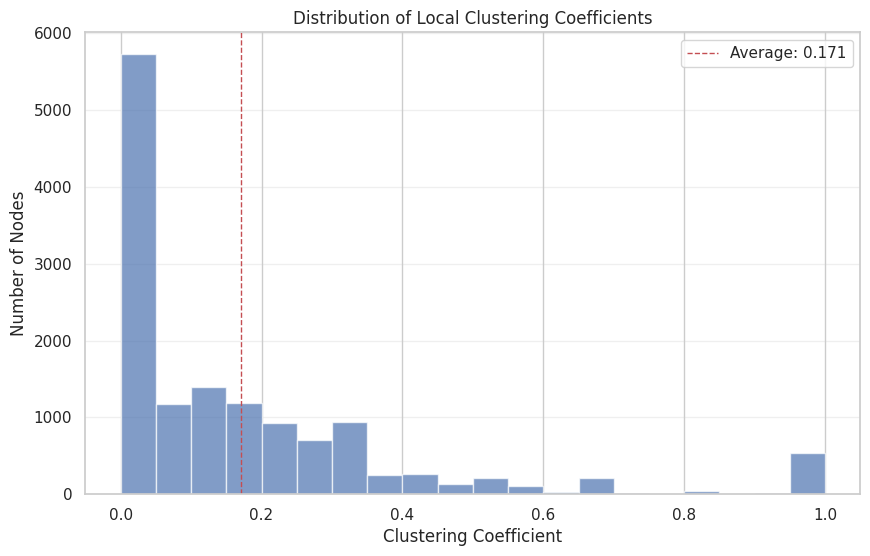

In [14]:
# Calculate the global clustering coefficient (transitivity)
global_clustering = nx.transitivity(G)
print(f"Global clustering coefficient (transitivity): {global_clustering:.4f}")

# Calculate the average local clustering coefficient
avg_local_clustering = nx.average_clustering(G)
print(f"Average local clustering coefficient: {avg_local_clustering:.4f}")

# Calculate local clustering coefficients for each node
clustering_coeffs = nx.clustering(G)

# Create a dataframe for analysis
clustering_df = pd.DataFrame.from_dict(clustering_coeffs, orient='index').reset_index()
clustering_df.columns = ['Node', 'Clustering Coefficient']

# Plot histogram of clustering coefficients
plt.figure(figsize=(10, 6))
plt.hist(clustering_df['Clustering Coefficient'], bins=20, alpha=0.7)
plt.xlabel('Clustering Coefficient')
plt.ylabel('Number of Nodes')
plt.title('Distribution of Local Clustering Coefficients')
plt.grid(True, axis='y', alpha=0.3)
plt.axvline(avg_local_clustering, color='r', linestyle='dashed', linewidth=1, 
            label=f'Average: {avg_local_clustering:.3f}')
plt.legend()
plt.show()

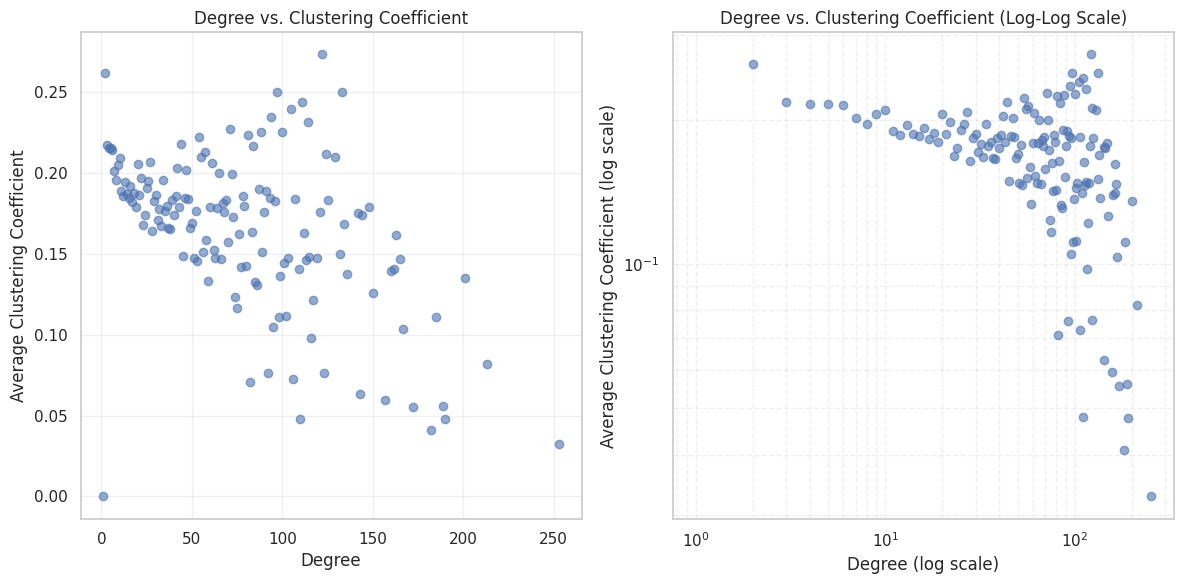

In [15]:
# Analyze the relationship between degree and clustering coefficient
degree_clustering = {}
for node in G.nodes():
    degree = G.degree(node)
    clustering = clustering_coeffs[node]
    if degree in degree_clustering:
        degree_clustering[degree].append(clustering)
    else:
        degree_clustering[degree] = [clustering]

# Calculate average clustering coefficient for each degree
avg_clustering_by_degree = {k: np.mean(v) for k, v in degree_clustering.items()}

# Convert to dataframe
dc_df = pd.DataFrame(list(avg_clustering_by_degree.items()), columns=['Degree', 'Avg Clustering'])
dc_df = dc_df.sort_values('Degree')

# Plot degree vs clustering coefficient
plt.figure(figsize=(12, 6))

# Regular plot
plt.subplot(121)
plt.scatter(dc_df['Degree'], dc_df['Avg Clustering'], alpha=0.6)
plt.xlabel('Degree')
plt.ylabel('Average Clustering Coefficient')
plt.title('Degree vs. Clustering Coefficient')
plt.grid(True, alpha=0.3)

# Log-log plot
plt.subplot(122)
plt.loglog(dc_df['Degree'], dc_df['Avg Clustering'], 'o', alpha=0.6)
plt.xlabel('Degree (log scale)')
plt.ylabel('Average Clustering Coefficient (log scale)')
plt.title('Degree vs. Clustering Coefficient (Log-Log Scale)')
plt.grid(True, which="both", ls="--", alpha=0.3)

plt.tight_layout()
plt.show()

## Centrality Analysis

In [11]:
# For large networks, computing centrality measures can be time-consuming
# We'll work with the largest connected component for this analysis

# Calculate degree centrality
degree_centrality = nx.degree_centrality(G_lcc)

# Calculate betweenness centrality (this might take some time)
print("Computing betweenness centrality (this might take a while)...")
# Use approximate betweenness with sampling for large networks
k = min(1000, G_lcc.number_of_nodes())  # Number of sample nodes
betweenness_centrality = nx.betweenness_centrality(G_lcc, k=k, normalized=True, seed=42)

# Calculate closeness centrality
print("Computing closeness centrality...")
closeness_centrality = nx.closeness_centrality(G_lcc)

# Create a dataframe with centrality measures
centrality_df = pd.DataFrame({
    'Node': list(G_lcc.nodes()),
    'Degree Centrality': [degree_centrality[n] for n in G_lcc.nodes()],
    'Betweenness Centrality': [betweenness_centrality[n] for n in G_lcc.nodes()],
    'Closeness Centrality': [closeness_centrality[n] for n in G_lcc.nodes()]
})

Computing betweenness centrality (this might take a while)...
Computing closeness centrality...


## Link Prediction

In [24]:
# Link Prediction using DGL
import torch
import torch.nn as nn
import torch.nn.functional as F
import dgl
import dgl.function as fn
from dgl.nn import GraphConv
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
import random

# Check if CUDA is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

print("Preparing data for link prediction...")

# Use a smaller subgraph for computational efficiency
top_nodes = list(centrality_df.sort_values('Degree Centrality', ascending=False).head(1000)['Node'])
subgraph = G_lcc.subgraph(top_nodes).copy()
print(f"Using a subgraph with {subgraph.number_of_nodes()} nodes and {subgraph.number_of_edges()} edges")

Using device: cpu
Preparing data for link prediction...
Using a subgraph with 1000 nodes and 15074 edges


In [ ]:
# Create node features
node_features = {}
for node in subgraph.nodes():
    # Node degree
    degree = subgraph.degree(node)
    
    # Local clustering coefficient
    clustering = nx.clustering(subgraph, node)
    
    # Try to get centrality measures
    try:
        deg_cent = nx.degree_centrality(subgraph)[node]
        # Use approximate betweenness with sampling for large networks
        bet_cent = nx.betweenness_centrality(subgraph, k=1000)[node]
        close_cent = nx.closeness_centrality(subgraph)[node]
    except:
        deg_cent = bet_cent = close_cent = 0
    
    node_features[node] = [degree, clustering, deg_cent, bet_cent, close_cent]

# Create a node mapping
node_mapping = {node: i for i, node in enumerate(subgraph.nodes())}
reverse_mapping = {i: node for node, i in node_mapping.items()}

# Get all edges and split them
all_edges = list(subgraph.edges())
random.shuffle(all_edges)

# Split edges into train/val/test
n_edges = len(all_edges)
train_edges = all_edges[:int(0.7*n_edges)]
val_edges = all_edges[int(0.7*n_edges):int(0.85*n_edges)]
test_edges = all_edges[int(0.85*n_edges):]

print(f"Train edges: {len(train_edges)}, Val edges: {len(val_edges)}, Test edges: {len(test_edges)}")

In [ ]:
# Create a graph with only training edges
train_graph = subgraph.copy()
train_graph.remove_edges_from(val_edges + test_edges)

# Create negative samples for validation and testing
def create_negative_edges(graph, n_samples, existing_edges):
    nodes = list(graph.nodes())
    negative_edges = []
    existing_edge_set = set(existing_edges + [(v, u) for u, v in existing_edges])  # Include both directions
    
    while len(negative_edges) < n_samples:
        u, v = random.sample(nodes, 2)
        if (u, v) not in existing_edge_set and (v, u) not in existing_edge_set and (u, v) not in negative_edges:
            negative_edges.append((u, v))
    
    return negative_edges

val_neg_edges = create_negative_edges(subgraph, len(val_edges), train_edges + test_edges)
test_neg_edges = create_negative_edges(subgraph, len(test_edges), train_edges + val_edges + val_neg_edges)

# Create feature matrix for nodes
features = np.array([node_features[node] for node in subgraph.nodes()])
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Convert to DGL graph
edges_src = []
edges_dst = []

for u, v in train_graph.edges():
    edges_src.append(node_mapping[u])
    edges_dst.append(node_mapping[v])
    # For undirected graphs, add the reverse edge
    edges_src.append(node_mapping[v])
    edges_dst.append(node_mapping[u])

dgl_graph = dgl.graph((torch.tensor(edges_src), torch.tensor(edges_dst)))
dgl_graph.ndata['feat'] = torch.FloatTensor(features_scaled)

# Convert the edge sets for DGL
def convert_edge_sets(edge_list, node_mapping):
    src = [node_mapping[u] for u, v in edge_list]
    dst = [node_mapping[v] for u, v in edge_list]
    return torch.tensor(src), torch.tensor(dst)

val_pos_src, val_pos_dst = convert_edge_sets(val_edges, node_mapping)
val_neg_src, val_neg_dst = convert_edge_sets(val_neg_edges, node_mapping)
test_pos_src, test_pos_dst = convert_edge_sets(test_edges, node_mapping)
test_neg_src, test_neg_dst = convert_edge_sets(test_neg_edges, node_mapping)

# Define the Link Prediction model using GraphSAGE
class LinkPrediction(nn.Module):
    def __init__(self, in_feats, h_feats):
        super(LinkPrediction, self).__init__()
        self.conv1 = GraphConv(in_feats, h_feats, allow_zero_in_degree=True)
        self.conv2 = GraphConv(h_feats, h_feats, allow_zero_in_degree=True)
        self.predict = nn.Sequential(
            nn.Linear(h_feats * 2, h_feats),
            nn.ReLU(),
            nn.Linear(h_feats, 1)
        )
    
    def forward(self, g, h):
        # Get node embeddings
        h = F.relu(self.conv1(g, h))
        h = self.conv2(g, h)
        return h
    
    def predict_link(self, h, src, dst):
        # Get embeddings for source and destination nodes
        h_src = h[src]
        h_dst = h[dst]
        # Concatenate embeddings and predict link probability
        h_concat = torch.cat([h_src, h_dst], dim=1)
        return torch.sigmoid(self.predict(h_concat)).squeeze()

In [ ]:
test_pos_src

In [ ]:
test_pos_dst

In [17]:
# Create the model
in_feats = features_scaled.shape[1]
h_feats = 32  # Hidden dimension size
model = LinkPrediction(in_feats, h_feats)

# Move everything to device
model = model.to(device)
dgl_graph = dgl_graph.to(device)
features = dgl_graph.ndata['feat'].to(device)
val_pos_src = val_pos_src.to(device)
val_pos_dst = val_pos_dst.to(device)
val_neg_src = val_neg_src.to(device)
val_neg_dst = val_neg_dst.to(device)
test_pos_src = test_pos_src.to(device)
test_pos_dst = test_pos_dst.to(device)
test_neg_src = test_neg_src.to(device)
test_neg_dst = test_neg_dst.to(device)

# Define the optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Define the loss function
loss_fn = nn.BCELoss()

# Training loop
best_val_auc = 0
best_model = None
patience = 20
counter = 0

print("\nTraining Link Prediction model...")
for epoch in range(200):
    model.train()
    
    # Forward pass
    h = model(dgl_graph, features)
    
    # Positive and negative samples for this epoch
    # Sample edges from training graph
    train_pos_src, train_pos_dst = dgl_graph.edges()
    # Use the sampled edges as positive samples, sample same number of negatives
    n_edges_to_sample = min(len(train_pos_src), 1000)  # Limit batch size
    idx = torch.randperm(len(train_pos_src))[:n_edges_to_sample]
    train_pos_src, train_pos_dst = train_pos_src[idx], train_pos_dst[idx]
    
    # Create negative samples
    train_neg_src = train_pos_src
    train_neg_dst = torch.randint(0, dgl_graph.number_of_nodes(), (n_edges_to_sample,), device=device)
    
    # Filter out existing edges from negative samples
    edge_set = set(zip(train_pos_src.cpu().numpy(), train_pos_dst.cpu().numpy()))
    neg_edges = []
    for i in range(len(train_neg_src)):
        src, dst = train_neg_src[i].item(), train_neg_dst[i].item()
        if (src, dst) not in edge_set and src != dst:
            neg_edges.append(i)
    
    train_neg_src = train_neg_src[neg_edges]
    train_neg_dst = train_neg_dst[neg_edges]
    
    # Make sure we have same number of positive and negative samples
    min_size = min(len(train_pos_src), len(train_neg_src))
    train_pos_src, train_pos_dst = train_pos_src[:min_size], train_pos_dst[:min_size]
    train_neg_src, train_neg_dst = train_neg_src[:min_size], train_neg_dst[:min_size]
    
    # Predict on positive and negative samples
    pos_score = model.predict_link(h, train_pos_src, train_pos_dst)
    neg_score = model.predict_link(h, train_neg_src, train_neg_dst)
    
    # Compute loss
    pos_loss = loss_fn(pos_score, torch.ones_like(pos_score))
    neg_loss = loss_fn(neg_score, torch.zeros_like(neg_score))
    loss = pos_loss + neg_loss
    
    # Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    # Validation
    model.eval()
    with torch.no_grad():
        h = model(dgl_graph, features)
        val_pos_score = model.predict_link(h, val_pos_src, val_pos_dst)
        val_neg_score = model.predict_link(h, val_neg_src, val_neg_dst)
        
        # Calculate validation AUC
        val_labels = torch.cat([torch.ones_like(val_pos_score), torch.zeros_like(val_neg_score)]).cpu().numpy()
        val_preds = torch.cat([val_pos_score, val_neg_score]).cpu().numpy()
        val_auc = roc_auc_score(val_labels, val_preds)
        
        # Save best model
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_model = {key: value.cpu() for key, value in model.state_dict().items()}
            counter = 0
        else:
            counter += 1
        
        # Early stopping
        if counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            break
    
    if epoch % 10 == 0:
        train_auc = roc_auc_score(
            torch.cat([torch.ones_like(pos_score), torch.zeros_like(neg_score)]).cpu().numpy(),
            torch.cat([pos_score, neg_score]).detach().cpu().numpy()
        )
        print(f"Epoch {epoch:03d} | Loss: {loss.item():.4f} | Train AUC: {train_auc:.4f} | Val AUC: {val_auc:.4f}")


Training Link Prediction model...
Epoch 000 | Loss: 1.3893 | Train AUC: 0.5074 | Val AUC: 0.6960
Epoch 010 | Loss: 1.1946 | Train AUC: 0.7178 | Val AUC: 0.7247
Epoch 020 | Loss: 1.0375 | Train AUC: 0.8165 | Val AUC: 0.8252
Epoch 030 | Loss: 0.9785 | Train AUC: 0.8344 | Val AUC: 0.8315
Epoch 040 | Loss: 0.9678 | Train AUC: 0.8423 | Val AUC: 0.8427
Epoch 050 | Loss: 0.9887 | Train AUC: 0.8314 | Val AUC: 0.8459
Epoch 060 | Loss: 0.9878 | Train AUC: 0.8309 | Val AUC: 0.8498
Epoch 070 | Loss: 0.9624 | Train AUC: 0.8367 | Val AUC: 0.8499
Epoch 080 | Loss: 0.9689 | Train AUC: 0.8320 | Val AUC: 0.8512
Epoch 090 | Loss: 0.9568 | Train AUC: 0.8379 | Val AUC: 0.8501
Epoch 100 | Loss: 0.9382 | Train AUC: 0.8425 | Val AUC: 0.8527
Epoch 110 | Loss: 0.9439 | Train AUC: 0.8425 | Val AUC: 0.8583
Epoch 120 | Loss: 0.9472 | Train AUC: 0.8379 | Val AUC: 0.8598
Epoch 130 | Loss: 0.9207 | Train AUC: 0.8475 | Val AUC: 0.8636
Epoch 140 | Loss: 0.8643 | Train AUC: 0.8679 | Val AUC: 0.8665
Epoch 150 | Loss: 0.

In [18]:
# Load the best model
if best_model is not None:
    model.load_state_dict(best_model)
    model = model.to(device)

# Evaluate on test set
model.eval()
with torch.no_grad():
    h = model(dgl_graph, features)
    test_pos_score = model.predict_link(h, test_pos_src, test_pos_dst)
    test_neg_score = model.predict_link(h, test_neg_src, test_neg_dst)
    
    # Calculate test metrics
    test_labels = torch.cat([torch.ones_like(test_pos_score), torch.zeros_like(test_neg_score)]).cpu().numpy()
    test_preds = torch.cat([test_pos_score, test_neg_score]).cpu().numpy()
    test_auc = roc_auc_score(test_labels, test_preds)
    
    # Binary predictions for other metrics
    test_binary_preds = (test_preds > 0.5).astype(int)
    test_acc = accuracy_score(test_labels, test_binary_preds)

print("\nDGL Link Prediction Results:")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test AUC: {test_auc:.4f}")
print("\nClassification Report:")
print(classification_report(test_labels, test_binary_preds))


DGL Link Prediction Results:
Test Accuracy: 0.8368
Test AUC: 0.8962

Classification Report:
              precision    recall  f1-score   support

         0.0       0.85      0.82      0.83       432
         1.0       0.82      0.86      0.84       432

    accuracy                           0.84       864
   macro avg       0.84      0.84      0.84       864
weighted avg       0.84      0.84      0.84       864



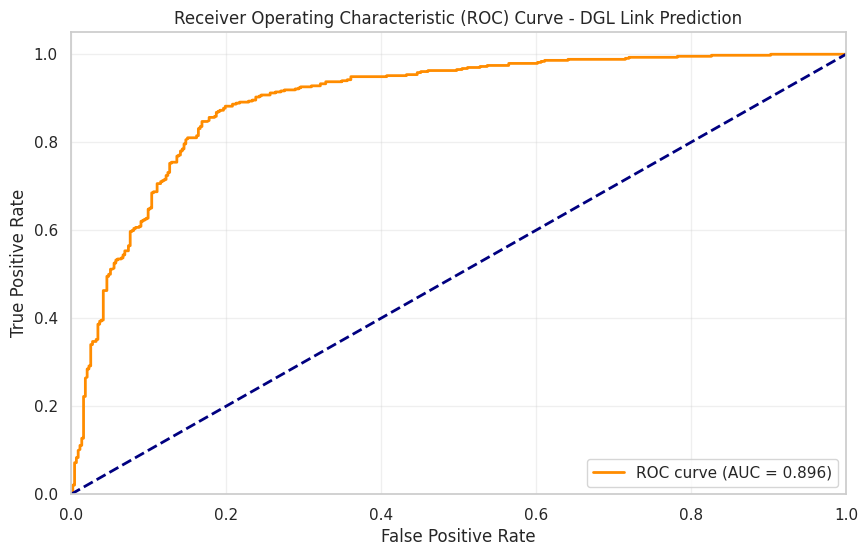

In [21]:
# Plot ROC curve
fpr, tpr, _ = roc_curve(test_labels, test_preds)
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {test_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - DGL Link Prediction')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()